# Fraud Detection Using Machine Learning Classification

### 1.1 Project Introduction

#### Problem Statement
> Predict whether a financial transaction is fraudulent or not fraudulent using transaction, customer, and behavioural information.

- **Type of Machine Learning Task:** Binary Classification
- **Target Variable:** `risk_label`
  - `0` = **Not Fraud** (Legitimate transaction)
  - `1` = **Fraud** (Fraudulent transaction)
- **Dataset File:** `datasets/fraud_detection.parquet`
- **Objective:** Build a complete, robust, and leakage-free classification pipeline supporting all 10 required machine learning classification algorithms.

### 1.2 Import Libraries
Importing the standard Python libraries for data loading, inspection, and visualization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling for clean, readable plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


### 1.3 Load Dataset
Loading the raw dataset from `datasets/fraud_detection.parquet`. We inspect the first and last 5 rows along with the dataset shape. The original dataset file remains completely unmodified.

In [2]:
# Portably resolve path whether running from project root or notebooks folder
data_path = os.path.join("..", "datasets", "fraud_detection.parquet") if os.path.exists(os.path.join("..", "datasets", "fraud_detection.parquet")) else os.path.join("datasets", "fraud_detection.parquet")

df = pd.read_parquet(data_path)

print(f"Dataset successfully loaded from: {data_path}")
print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dataset successfully loaded from: ..\datasets\fraud_detection.parquet
Dataset Shape: 100,000 rows x 21 columns


In [3]:
# Display the first 5 rows
df.head()

,transaction_id,customer_id,transaction_hour,transaction_day_of_week,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,transaction_type,...,is_international,is_high_risk_merchant_category,is_weekend,customer_total_transactions_30d,customer_risk_score,transaction_amount,avg_transaction_amount_30d_customer,transaction_velocity_1h,transaction_velocity_24h,risk_label
0,TXN0000000,CUST08775,14,1,96,0,gambling,US,mobile,online,...,0,1,0,10,0.64,564.90,739.13,0,3,0
1,TXN0000001,CUST03912,20,0,483,0,online_services,CA,mobile,pos,...,1,1,0,6,0.14,216.96,459.92,1,5,0
2,TXN0000002,CUST07040,22,4,1135,0,fuel,UK,mobile,pos,...,1,0,0,6,0.00,113.20,263.86,0,1,0
3,TXN0000003,CUST04806,23,3,714,0,travel,US,desktop,pos,...,0,1,0,13,0.00,1566.23,793.96,1,1,0
4,TXN0000004,CUST00658,2,1,553,0,travel,CA,mobile,online,...,1,1,0,8,0.00,313.21,942.81,0,3,0


In [4]:
# Display the last 5 rows
df.tail()

,transaction_id,customer_id,transaction_hour,transaction_day_of_week,account_age_days,previous_chargebacks,merchant_category,transaction_country,device_type,transaction_type,...,is_international,is_high_risk_merchant_category,is_weekend,customer_total_transactions_30d,customer_risk_score,transaction_amount,avg_transaction_amount_30d_customer,transaction_velocity_1h,transaction_velocity_24h,risk_label
99995,TXN0099995,CUST06720,8,0,694,0,grocery,US,tablet,online,...,0,0,0,8,0.27,257.28,1171.72,4,6,0
99996,TXN0099996,CUST07222,3,2,166,0,digital_subscriptions,IN,mobile,pos,...,1,0,0,10,0.67,1038.01,641.63,0,1,0
99997,TXN0099997,CUST02369,13,4,507,0,digital_subscriptions,AU,mobile,atm_withdrawal,...,1,0,0,10,0.00,374.49,2068.11,0,1,0
99998,TXN0099998,CUST04611,23,6,486,0,travel,IN,mobile,pos,...,1,1,1,9,0.16,1234.06,639.65,0,0,0
99999,TXN0099999,CUST03762,17,2,746,0,digital_subscriptions,US,desktop,pos,...,0,0,0,7,0.18,228.11,872.30,0,2,0


### 2.1 Dataset Shape
Displaying the exact number of rows and columns in the dataset.

In [5]:
n_rows, n_cols = df.shape
print(f"Total Rows:    {n_rows:,}")
print(f"Total Columns: {n_cols}")

Total Rows:    100,000
Total Columns: 21


### 2.2 Column Names
Displaying all 21 column names in the dataset.

In [6]:
print("All Column Names in Dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

All Column Names in Dataset:
 1. transaction_id
 2. customer_id
 3. transaction_hour
 4. transaction_day_of_week
 5. account_age_days
 6. previous_chargebacks
 7. merchant_category
 8. transaction_country
 9. device_type
10. transaction_type
11. geo_location_region
12. is_international
13. is_high_risk_merchant_category
14. is_weekend
15. customer_total_transactions_30d
16. customer_risk_score
17. transaction_amount
18. avg_transaction_amount_30d_customer
19. transaction_velocity_1h
20. transaction_velocity_24h
21. risk_label


### 2.3 Data Types
Displaying the data types of each column.

In [7]:
df.dtypes

transaction_id                             str
customer_id                                str
transaction_hour                         int64
transaction_day_of_week                  int64
account_age_days                         int64
previous_chargebacks                     int64
merchant_category                          str
transaction_country                        str
device_type                                str
transaction_type                           str
geo_location_region                        str
is_international                         int64
is_high_risk_merchant_category           int64
is_weekend                               int64
customer_total_transactions_30d          int64
customer_risk_score                    float64
transaction_amount                     float64
avg_transaction_amount_30d_customer    float64
transaction_velocity_1h                  int64
transaction_velocity_24h                 int64
risk_label                               int64
dtype: object

### 2.4 Missing Values
Auditing missing-value counts and percentages for every column.

In [8]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)': (df.isnull().mean() * 100).round(2)
})
missing_df

,Missing Count,Missing (%)
transaction_id,0,0.0
customer_id,0,0.0
transaction_hour,0,0.0
transaction_day_of_week,0,0.0
account_age_days,0,0.0
previous_chargebacks,0,0.0
merchant_category,0,0.0
transaction_country,0,0.0
device_type,0,0.0
transaction_type,0,0.0


### 2.5 Duplicate Rows
Checking for exact duplicate rows across all columns. No rows are removed in this commit.

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Exact Duplicate Rows: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)")

Exact Duplicate Rows: 0 (0.00%)


### 2.6 Unique Values
Displaying the number of unique values (cardinality) for each column.

In [10]:
df.nunique()

transaction_id                         100000
customer_id                              9999
transaction_hour                           24
transaction_day_of_week                     7
account_age_days                         3272
previous_chargebacks                        6
merchant_category                          10
transaction_country                        10
device_type                                 4
transaction_type                            4
geo_location_region                         5
is_international                            2
is_high_risk_merchant_category              2
is_weekend                                  2
customer_total_transactions_30d            26
customer_risk_score                       618
transaction_amount                      71561
avg_transaction_amount_30d_customer     66574
transaction_velocity_1h                     9
transaction_velocity_24h                   16
risk_label                                  2
dtype: int64

### 3.1 Target Check
Checking the target column `risk_label` to confirm it exists and contains only the binary classes 0 and 1.

In [11]:
print(f"Target column 'risk_label' exists: {'risk_label' in df.columns}")
print(f"Unique target values: {sorted(df['risk_label'].unique().tolist())}")
print(f"Target data type:     {df['risk_label'].dtype}")

Target column 'risk_label' exists: True
Unique target values: [0, 1]
Target data type:     int64


### 3.2 Class Counts
Displaying the count of legitimate (Not Fraud) and fraudulent transactions.

In [12]:
class_counts = df['risk_label'].value_counts().sort_index()
not_fraud_count = class_counts[0]
fraud_count = class_counts[1]

print(f"Class 0 (Not Fraud): {not_fraud_count:,} transactions")
print(f"Class 1 (Fraud):     {fraud_count:,} transactions")

Class 0 (Not Fraud): 98,500 transactions
Class 1 (Fraud):     1,500 transactions


### 3.3 Class Percentages
Calculating the class proportions and the class imbalance ratio.

In [13]:
not_fraud_pct = (not_fraud_count / len(df)) * 100
fraud_pct = (fraud_count / len(df)) * 100
imbalance_ratio = not_fraud_count / fraud_count

print(f"Class 0 (Not Fraud): {not_fraud_pct:.2f}%")
print(f"Class 1 (Fraud):     {fraud_pct:.2f}%")
print(f"Imbalance Ratio:     {imbalance_ratio:.2f} : 1")

Class 0 (Not Fraud): 98.50%
Class 1 (Fraud):     1.50%
Imbalance Ratio:     65.67 : 1


### 3.4 Target Distribution Plot
Creating a count plot to visualize the class distribution of `risk_label`.

C:\Users\anish\AppData\Local\Temp\ipykernel_22476\2320507670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='risk_label', data=df, palette=['#2b5c8f', '#d9534f'])


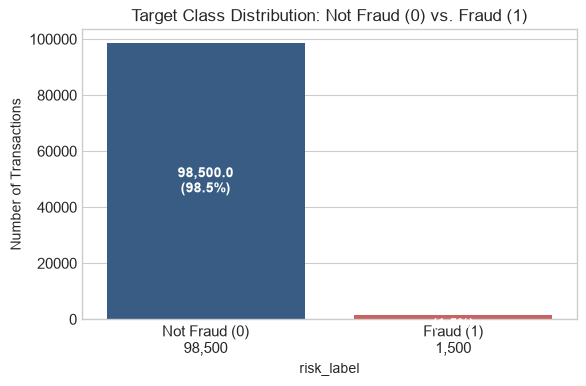

In [14]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='risk_label', data=df, palette=['#2b5c8f', '#d9534f'])
plt.title('Target Class Distribution: Not Fraud (0) vs. Fraud (1)')
plt.xlabel('risk_label')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Not Fraud (0)\n98,500', 'Fraud (1)\n1,500'])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}\n({height/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

> **Observation:** The dataset is highly imbalanced, with many more legitimate transactions ($98.50\%$) than fraudulent transactions ($1.50\%$). Therefore, accuracy alone may not be sufficient for evaluating the models later. A trivial model predicting 0 for all instances would achieve $98.50\%$ accuracy while failing to detect any fraud.

### 4.1 Identifier Columns
Identifying columns that represent unique record or entity identifiers. These columns are kept as-is in this commit and will not be dropped yet.

In [15]:
id_cols = ['transaction_id', 'customer_id']
print(f"Identifier columns ({len(id_cols)}): {id_cols}")
df[id_cols].head(3)

Identifier columns (2): ['transaction_id', 'customer_id']


,transaction_id,customer_id
0,TXN0000000,CUST08775
1,TXN0000001,CUST03912
2,TXN0000002,CUST07040


### 4.2 Numerical Features
Listing the continuous and discrete numerical features describing transactions, account history, and transaction velocity.

In [16]:
num_cols = [
    'transaction_hour', 'transaction_day_of_week', 'account_age_days',
    'previous_chargebacks', 'customer_total_transactions_30d', 'customer_risk_score',
    'transaction_amount', 'avg_transaction_amount_30d_customer',
    'transaction_velocity_1h', 'transaction_velocity_24h'
]
print(f"Numerical features ({len(num_cols)}):")
for col in num_cols:
    print(f"- {col}")

Numerical features (10):
- transaction_hour
- transaction_day_of_week
- account_age_days
- previous_chargebacks
- customer_total_transactions_30d
- customer_risk_score
- transaction_amount
- avg_transaction_amount_30d_customer
- transaction_velocity_1h
- transaction_velocity_24h


### 4.3 Categorical Features
Listing nominal categorical features representing business categories, countries, channels, and device types.

In [17]:
cat_cols = [
    'merchant_category', 'transaction_country', 'device_type',
    'transaction_type', 'geo_location_region'
]
print(f"Categorical features ({len(cat_cols)}):")
for col in cat_cols:
    print(f"- {col} ({df[col].nunique()} unique categories)")

Categorical features (5):
- merchant_category (10 unique categories)
- transaction_country (10 unique categories)
- device_type (4 unique categories)
- transaction_type (4 unique categories)
- geo_location_region (5 unique categories)


### 4.4 Binary Features
Listing the binary flag features (0 or 1).

In [18]:
bin_cols = [
    'is_international', 'is_high_risk_merchant_category', 'is_weekend'
]
print(f"Binary features ({len(bin_cols)}):")
for col in bin_cols:
    print(f"- {col}")

Binary features (3):
- is_international
- is_high_risk_merchant_category
- is_weekend


### 5.1 Numerical Summary
Using descriptive statistics to inspect ranges, medians, and dispersion across all numerical features.

In [19]:
df[num_cols].describe().round(2)

,transaction_hour,transaction_day_of_week,account_age_days,previous_chargebacks,customer_total_transactions_30d,customer_risk_score,transaction_amount,avg_transaction_amount_30d_customer,transaction_velocity_1h,transaction_velocity_24h
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,11.49,2.98,830.02,0.18,5.99,0.64,730.43,732.43,0.71,2.86
std,6.93,2.00,565.32,0.64,3.74,1.04,806.06,438.76,0.89,1.96
min,0.00,0.00,30.00,0.00,1.00,0.00,7.92,18.15,0.00,0.00
25%,5.00,1.00,414.00,0.00,3.00,0.00,257.32,475.69,0.00,1.00
50%,11.00,3.00,703.00,0.00,6.00,0.15,484.15,651.04,0.00,3.00
75%,18.00,5.00,1109.00,0.00,8.00,0.72,907.02,879.42,1.00,4.00
max,23.00,6.00,6307.00,5.00,27.00,7.72,15000.00,13134.66,8.00,15.00


### 5.2 Categorical Summary
Inspecting categorical feature counts, unique levels, and top occurring categories.

In [20]:
df[cat_cols].describe()

,merchant_category,transaction_country,device_type,transaction_type,geo_location_region
count,100000,100000,100000,100000,100000
unique,10,10,4,4,5
top,travel,US,mobile,online,North America
freq,10096,54954,54661,40031,50026


### 5.3 Fraud vs Not Fraud Summary
Comparing group means between legitimate (`risk_label = 0`) and fraudulent (`risk_label = 1`) transactions for key numerical indicators.

In [21]:
key_features = [
    'customer_risk_score', 'previous_chargebacks', 'transaction_amount',
    'avg_transaction_amount_30d_customer', 'transaction_velocity_1h',
    'transaction_velocity_24h', 'account_age_days'
]

group_summary = df.groupby('risk_label')[key_features].mean().T
group_summary.columns = ['Not Fraud (0) Mean', 'Fraud (1) Mean']
group_summary['Difference (Fraud - Not Fraud)'] = group_summary['Fraud (1) Mean'] - group_summary['Not Fraud (0) Mean']
group_summary.round(2)

,Not Fraud (0) Mean,Fraud (1) Mean,Difference (Fraud - Not Fraud)
customer_risk_score,0.60,3.67,3.07
previous_chargebacks,0.15,1.75,1.59
transaction_amount,720.54,1380.07,659.53
avg_transaction_amount_30d_customer,732.37,736.24,3.87
transaction_velocity_1h,0.69,1.70,1.01
transaction_velocity_24h,2.82,4.94,2.12
account_age_days,830.76,780.97,-49.80


### 6.1 Possible Identifier Columns
- `transaction_id`: Unique alphanumeric key for each transaction (`TXN0000000` to `TXN00099999`).
- `customer_id`: Customer identifier (`CUST00001` to `CUST09999`).

Identifiers do not represent generalizable behavioral patterns. In subsequent preprocessing milestones, these columns will be considered for removal to prevent models from memorizing specific identifiers rather than genuine transaction patterns.

### 6.2 Possible Risk-Related Features
- `previous_chargebacks`: Represents historical dispute counts on file before the transaction occurs.
- `customer_risk_score`: A pre-calculated credit/behavioral risk score.
- `transaction_velocity_1h` & `transaction_velocity_24h`: Transaction frequency within preceding time windows.
- `is_high_risk_merchant_category`: A flag indicating whether the merchant operates in historically high-risk sectors (e.g., gambling or luxury goods).

These features will be evaluated carefully in later preprocessing and feature engineering steps to verify that they reflect only information available at the time of transaction authorization and do not introduce post-transaction leakage or unneeded redundancy.

*Note: In accordance with Commit 7 requirements, no columns or rows are removed or modified in this commit.*

## 7. Commit 7 Summary

### 7.1 Dataset Summary
- **Dataset Dimensions:** $100,000$ rows $\times 21$ columns
- **Feature Count:** 20 predictor columns (10 numerical, 5 categorical, 3 binary, 2 identifiers)
- **Target Variable:** `risk_label` (binary: 0 = Not Fraud, 1 = Fraud)

### 7.2 Class Balance Summary
- **Not Fraud (Class 0):** $98,500$ rows ($98.50\%$)
- **Fraud (Class 1):** $1,500$ rows ($1.50\%$)
- **Imbalance Ratio:** $65.67 : 1$

### 7.3 Data Quality Summary
- **Missing Values:** $0$ missing values ($0.00\%$ across all columns)
- **Duplicate Rows:** $0$ exact duplicate rows ($0.00\%$)

### 7.4 Initial Observation
The dataset is clean and complete with no missing values or duplicate records. It reflects realistic real-world class imbalance where legitimate transactions heavily outnumber fraud cases. This will guide our preprocessing, stratified train/test split, and metric selection (prioritizing Recall, Precision, F1-score, and ROC-AUC over simple Accuracy) in subsequent milestones.